# LABORATORIUM 6 - LAS LOSOWY.

## 6.1 Implementacja lasu losowego

In [2]:
import numpy as np
from sklearn.datasets import make_blobs, make_classification, make_moons
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


#### Funkcje do generowania danych oraz do wyświetlania wyników:

In [3]:
def generate_data(n_samples, n_features, random_state):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=random_state
    )
    # y = 2 * y - 1
    return X, y

def generate_moons(n_samples, random_state):
    X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=random_state)
    # y_moons = 2 * y_moons - 1
    return X_moons, y_moons

def generate_blobs(n_samples, n_features, random_state, split_data=[0, 1]):
    centers_multi = [
        (-5, -5), (-5, 5),  
        (5, -5), (5, 5) 
    ]
    X_uni, y_uni = make_blobs(n_samples=n_samples, centers=centers_multi, n_features=n_features, random_state=random_state)
    y_uni = np.where(np.isin(y_uni, split_data), 0, 1)
    # y_uni = 2 * y_uni - 1
    return X_uni, y_uni

In [4]:
def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()


### Własna implementacja funkcji lasu losowego:

##### Drzewo losowe:

In [120]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class RandomTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None
        self.n_classes = None
        self.n_features = None
        self.max_features = None

    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        y = y.astype(np.int64)
        self.n_features = X.shape[1]
        self.max_features = int(math.sqrt(self.n_features))
        self.tree = self.build_tree(X, y)

    def gini(self, y):
        counts = np.bincount(y, minlength=self.n_classes)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def information_gain(self, X, y, feature, threshold):
        parent_gini = self.gini(y)
        feature_data = X[:, feature]
        left_mask = feature_data <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0: 
            return 0

        left_gini = self.gini(y[left_mask])
        right_gini = self.gini(y[right_mask])
        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        child_gini = (n_left / n) * left_gini + (n_right / n) * right_gini
        return parent_gini - child_gini


    def find_best_threshold(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        feature_indices = np.random.choice(self.n_features, self.max_features, replace=False)

        for feature in feature_indices:
            feature_values = X[:, feature]
            percentiles = np.percentile(feature_values, np.arange(10, 100, 10))
            thresholds = np.unique(percentiles)
            for threshold in thresholds:
                gain = self.information_gain(X, y, feature, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        n_samples = len(y)
        n_labels = len(np.unique(y))
        if n_labels == 1:
            return Node(value=y[0])
        if n_samples == 0:
            return Node(value=0)
        if self.max_depth is not None and depth >= self.max_depth:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        feature, threshold = self.find_best_threshold(X, y)
        if feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        feature_data = X[:, feature]
        left_mask = feature_data <= threshold
        right_mask = ~left_mask
        left = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature, threshold, left, right)
    
    def prepare_predict(self, x):
        node = self.tree
        while node.value is None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X):
        predictions = [self.prepare_predict(x) for x in X]
        return np.array(predictions)
    
    def print_tree(self, node=None, depth=0, prefix=""):
        if node is None:
            node = self.tree
        
        indent = "  " * depth
        if node.value is not None:
            print(f"{indent}{prefix}Liść: klasa={node.value}")
            return
        
        print(f"{indent}{prefix}Cecha {node.feature} <= {node.threshold:.4f}")
        
        self.print_tree(node.left, depth + 1, prefix="L--- ")
        self.print_tree(node.right, depth + 1, prefix="R--- ")

##### Las losowy:

In [ ]:
class RandomForest:
    def __init__(self, n_trees=100, max_depth=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = None
        self.trees = []
        self.bootstrap_indices = []
        self.oob_indices = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.max_features = int(np.sqrt(X.shape[1]))

        for _ in range(self.n_trees):
            choose_indices = np.random.choice(n_samples, n_samples, replace=True)
            oob = np.setdiff1d(np.arange(n_samples), choose_indices)
            self.bootstrap_indices.append(choose_indices)
            self.oob_indices.append(oob)

            tree = RandomTree(max_depth=self.max_depth)
            tree.fit(X[choose_indices], y[choose_indices])
            self.trees.append(tree)

    def predict(self, X):
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        y_pred = []
        for preds in tree_predictions.T:
            y_pred.append(np.bincount(preds).argmax())
        return np.array(y_pred)
    
    def oob_error(self, X, y, n_trees=None):
        if n_trees is None:
            n_trees = len(self.trees)
        n_samples = X.shape[0]

        votes = [list() for _ in range(n_samples)]
        for tree, oob_idx in zip(self.trees[:n_trees], self.oob_indices[:n_trees]): # klasyfikacja dla każdego drzewa z próbkami oob
            predictions = tree.predict(X[oob_idx])
            for idx, pred in zip(oob_idx, predictions): # dla danych próbek oob zapisujemy przewidywania
                votes[idx].append(pred)
        
        oob_preds = np.array([np.bincount(v).argmax() if len(v) > 0 else -1 for v in votes]) # dla każdej próbki oob wybieramy najczęściej występującą klasę
        mask = oob_preds != -1
        if not np.any(mask):
            return 1.0 
        accuracy = np.mean(oob_preds[mask] == y[mask])
        return 1.0 - accuracy 
    
    def print_trees(self):
        for i, tree in enumerate(self.trees):
            print(f"Drzewo {i + 1}:")
            tree.print_tree()
            print("\n" + "=" * 40 + "\n")   

#### Funkcja do obliczania i wyświetlania wykresu OOB:

In [7]:
def select_n_estimators(X, y, max_estimators=30):
    best_score = float('inf')
    best_n = 1
    oob_errors = []
    n_estimators_range = range(1, max_estimators + 1)
    
    for n in n_estimators_range:
        rf = RandomForest(n_trees=n, max_depth=10)
        rf.fit(X, y)
        score = rf.oob_error(X, y)
        oob_errors.append(score)
        if score < best_score:
            best_score = score
            best_n = n
    
    # Tworzenie wykresu
    plt.figure(figsize=(8, 6))
    plt.plot(n_estimators_range, oob_errors, marker='o', color='blue', label='Błąd OOB')
    plt.scatter([best_n], [best_score], color='red', s=100, label=f'Najlepsze n={best_n}, błąd={best_score:.4f}')
    plt.xlabel('Liczba drzew (n_estimators)')
    plt.ylabel('Błąd OOB')
    plt.title('Błąd OOB w zależności od liczby drzew')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return best_n

#### Klasyfikacja modeli na *Generate data*:

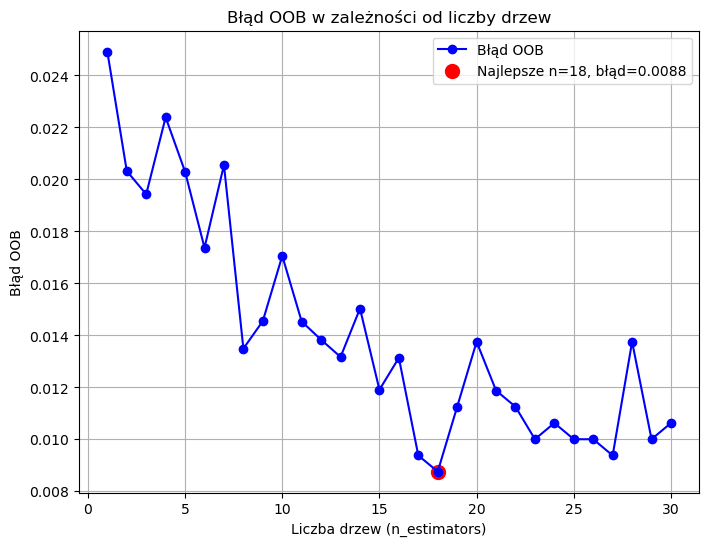

Znajdowana liczba drzew: 18
Czas wykonania własnego modelu: 4.187255 sekund
Własny model na Generate Data:
Skuteczność: 99.2500%
Czułość (Recall): 98.4615%
Swoistość: 100.0000%
ROC AUC: 0.9923


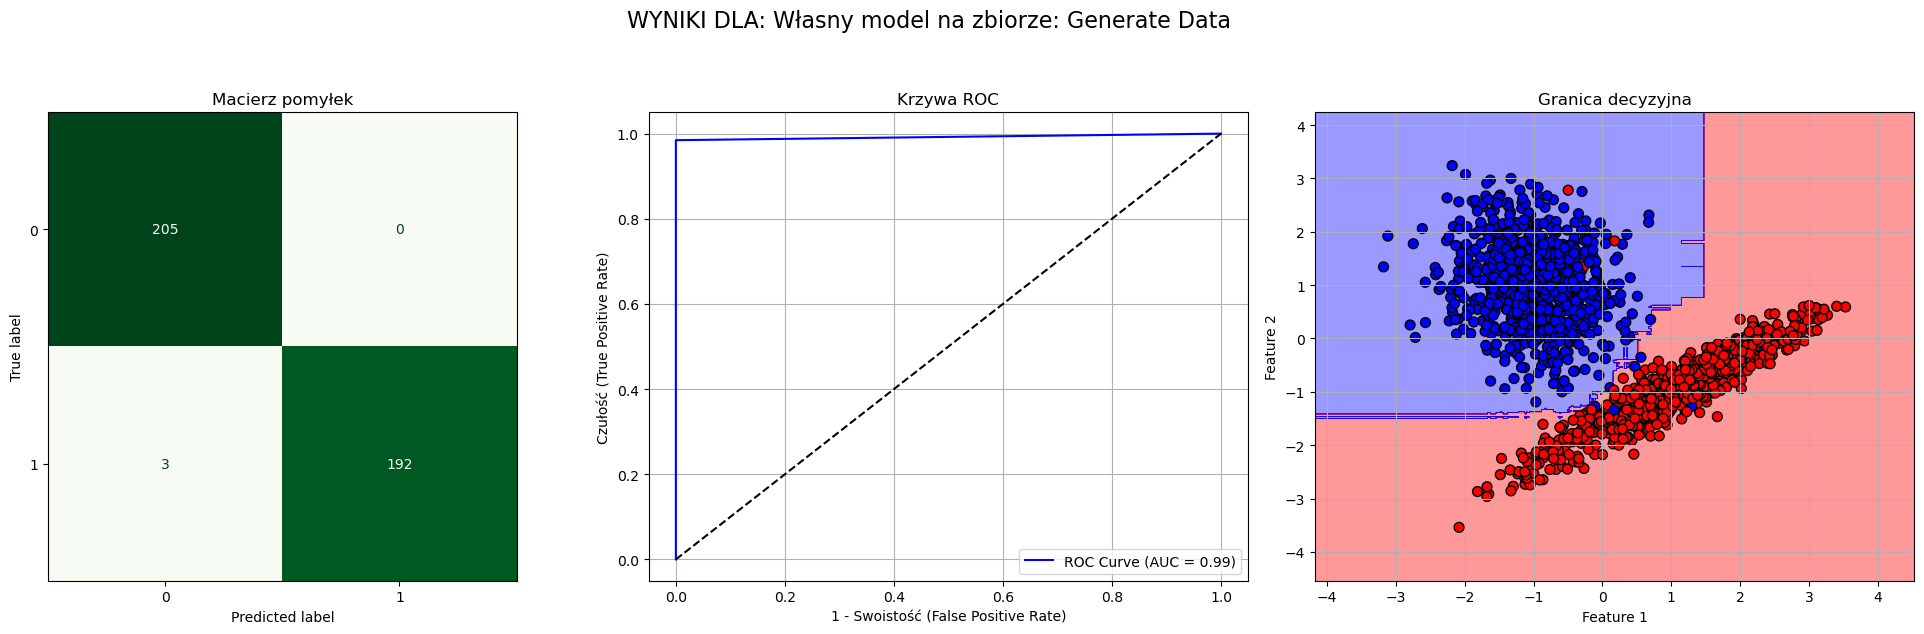

c:\Users\jasin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\jasin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\jasin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\jasin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\jasin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probab

Czas wykonania modelu sklearn: 0.361969 sekund
Sklearn na Generate Data:
Skuteczność: 99.7500%
Czułość (Recall): 99.4872%
Swoistość: 100.0000%
ROC AUC: 0.9974


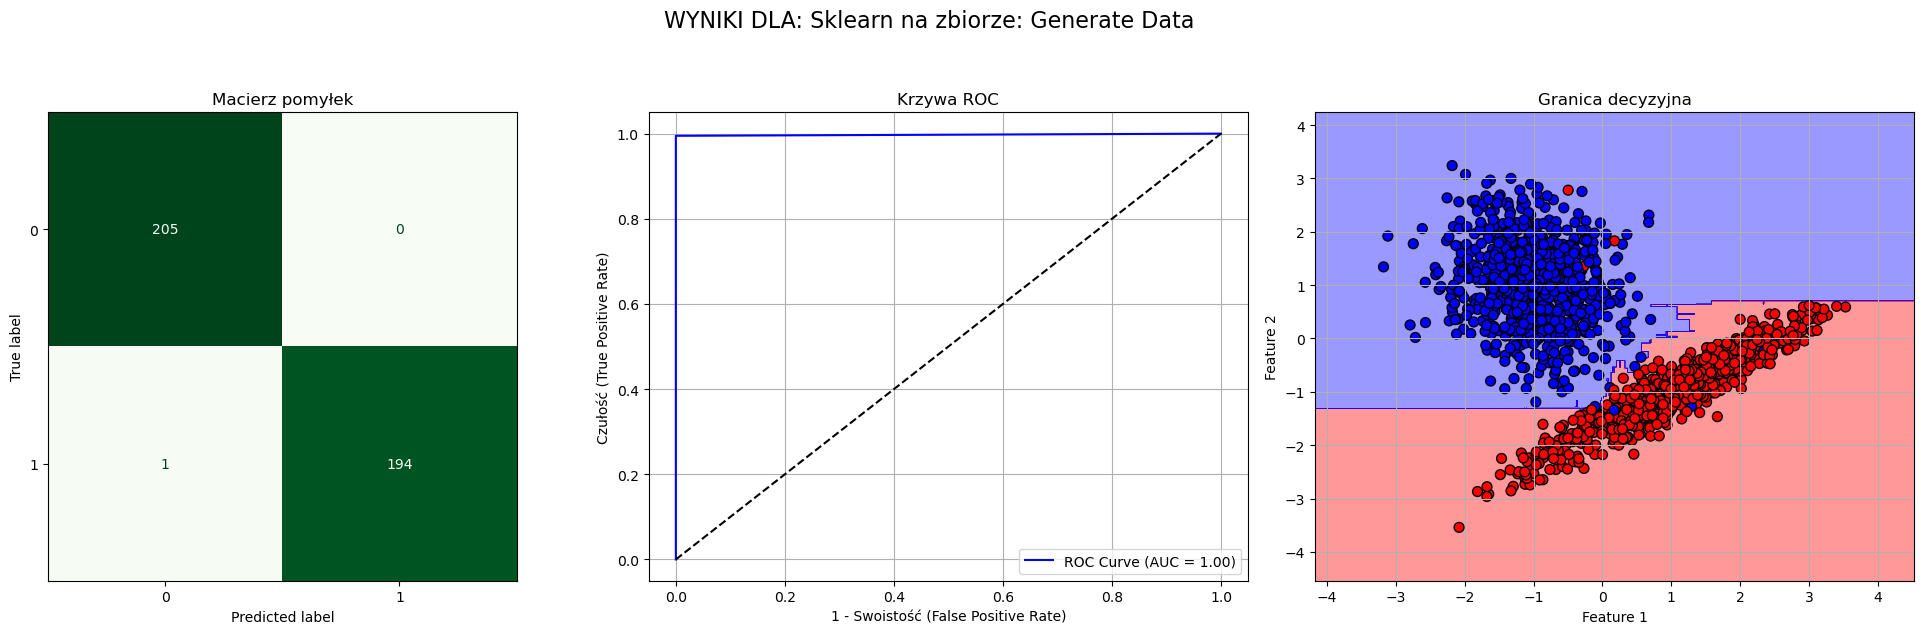

In [8]:
import time

X_generate, y_generate = generate_data(2000, 2, 259195)
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(X_generate, y_generate, test_size=0.2, random_state=259195)

n_estimators_1 = select_n_estimators(X_gen_train, y_gen_train)
print(f"Znajdowana liczba drzew: {n_estimators_1}")

start = time.time()
for _ in range(10):
    rf1 = RandomForest(n_trees=n_estimators_1, max_depth=10)
    rf1.fit(X_gen_train, y_gen_train)
    y_gen_pred = rf1.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania własnego modelu: {end - start:.6f} sekund")
evaluate_classifier(y_gen_test, y_gen_pred, X_gen_train, y_gen_train, rf1, "Własny model", "Generate Data")

start = time.time()
for _ in range(10):
    sk_rf2 = RandomForestClassifier(n_estimators=n_estimators_1, max_depth=10, max_features='sqrt', oob_score=True, bootstrap=True, random_state=42)
    sk_rf2.fit(X_gen_train, y_gen_train)
    sk_y2_pred = sk_rf2.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania modelu sklearn: {end - start:.6f} sekund")
evaluate_classifier(y_gen_test, sk_y2_pred, X_gen_train, y_gen_train, sk_rf2, "Sklearn", "Generate Data")

#### Klasyfikacja modeli na *Make moons*:

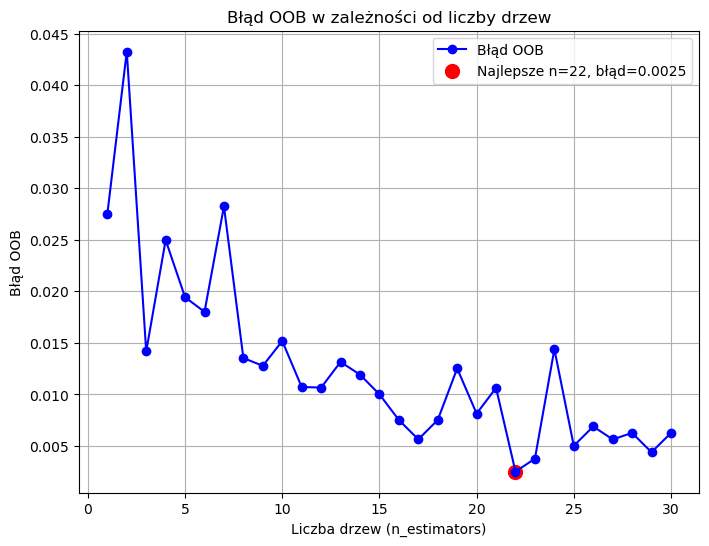

Znaleziona liczba drzew: 22
Czas wykonania własnego modelu: 5.183418 sekund
Własny model na Make Moons:
Skuteczność: 99.7500%
Czułość (Recall): 99.4737%
Swoistość: 100.0000%
ROC AUC: 0.9974


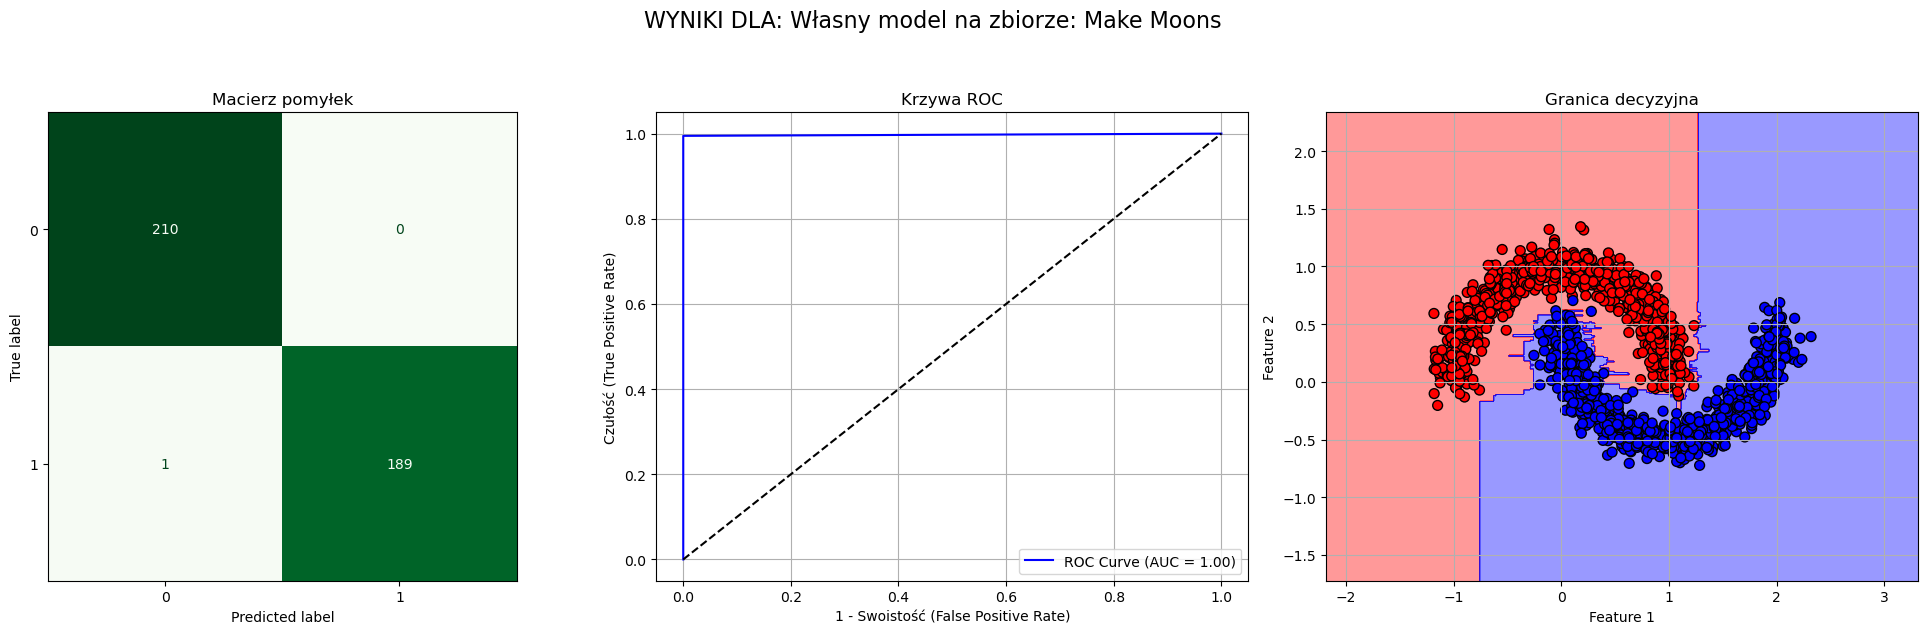

Czas wykonania modelu sklearn: 0.303010 sekund
Sklearn na Make Moons:
Skuteczność: 100.0000%
Czułość (Recall): 100.0000%
Swoistość: 100.0000%
ROC AUC: 1.0000


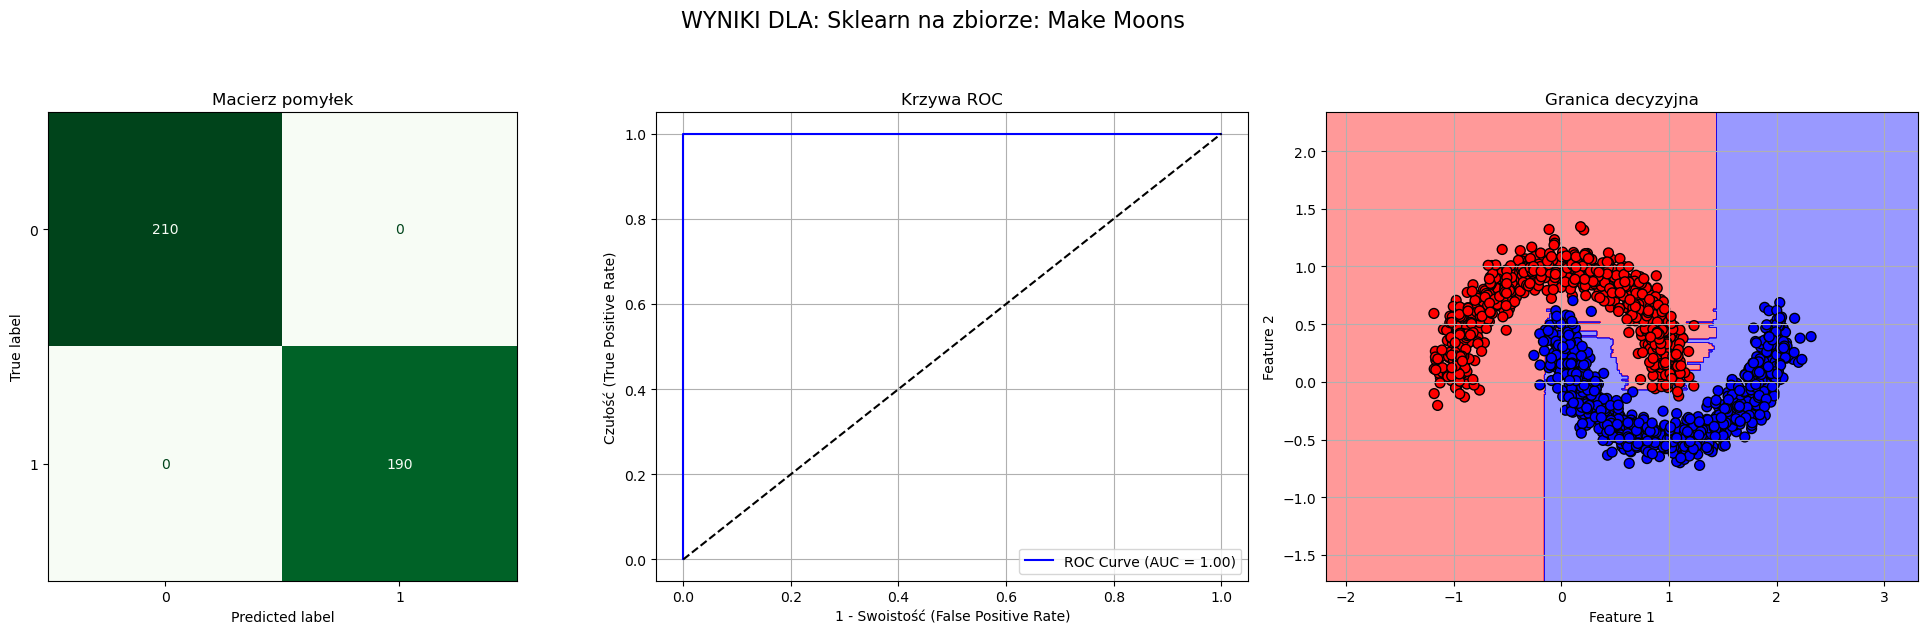

In [9]:
X_moons, y_moons = generate_moons(2000, 259195)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=259195)

n_estimators_2 = select_n_estimators(X_m_train, y_m_train)
print(f"Znaleziona liczba drzew: {n_estimators_2}")

start = time.time()
for _ in range(10):
    rf2 = RandomForest(n_trees=n_estimators_2, max_depth=10)
    rf2.fit(X_m_train, y_m_train)
    y2_pred = rf2.predict(X_m_test)
end = time.time()
print(f"Czas wykonania własnego modelu: {end - start:.6f} sekund")
evaluate_classifier(y_m_test, y2_pred, X_m_train, y_m_train, rf2, "Własny model", "Make Moons")

start = time.time()
for _ in range(10):
    sk_rf2 = RandomForestClassifier(n_estimators=n_estimators_2, max_depth=10, max_features='sqrt', oob_score=True, bootstrap=True, random_state=42)
    sk_rf2.fit(X_m_test, y_m_test)
    sk_y2_pred = sk_rf2.predict(X_m_test)
end = time.time()
print(f"Czas wykonania modelu sklearn: {end - start:.6f} sekund")
evaluate_classifier(y_m_test, sk_y2_pred, X_m_train, y_m_train, sk_rf2, "Sklearn", "Make Moons")

#### Klasyfikacja modeli na wielomodowym *Make blobs*:

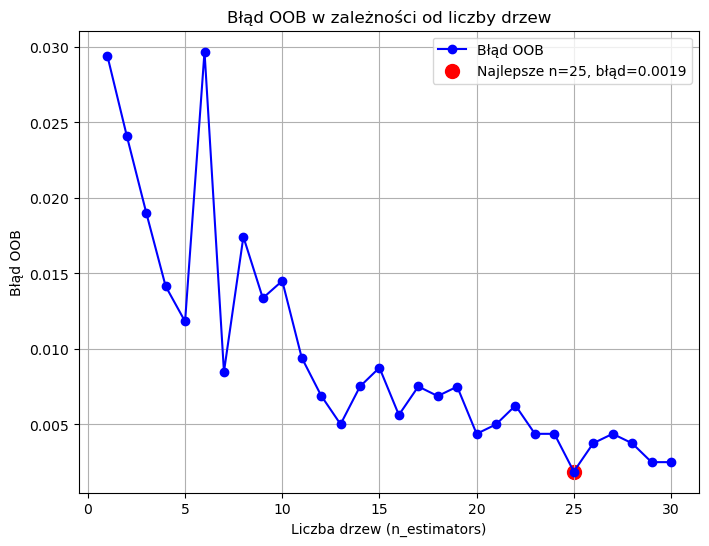

Znaleziona liczba drzew: 25
Czas wykonania własnego modelu: 6.425844 sekund
Własny model na Make Blobs:
Skuteczność: 100.0000%
Czułość (Recall): 100.0000%
Swoistość: 100.0000%
ROC AUC: 1.0000


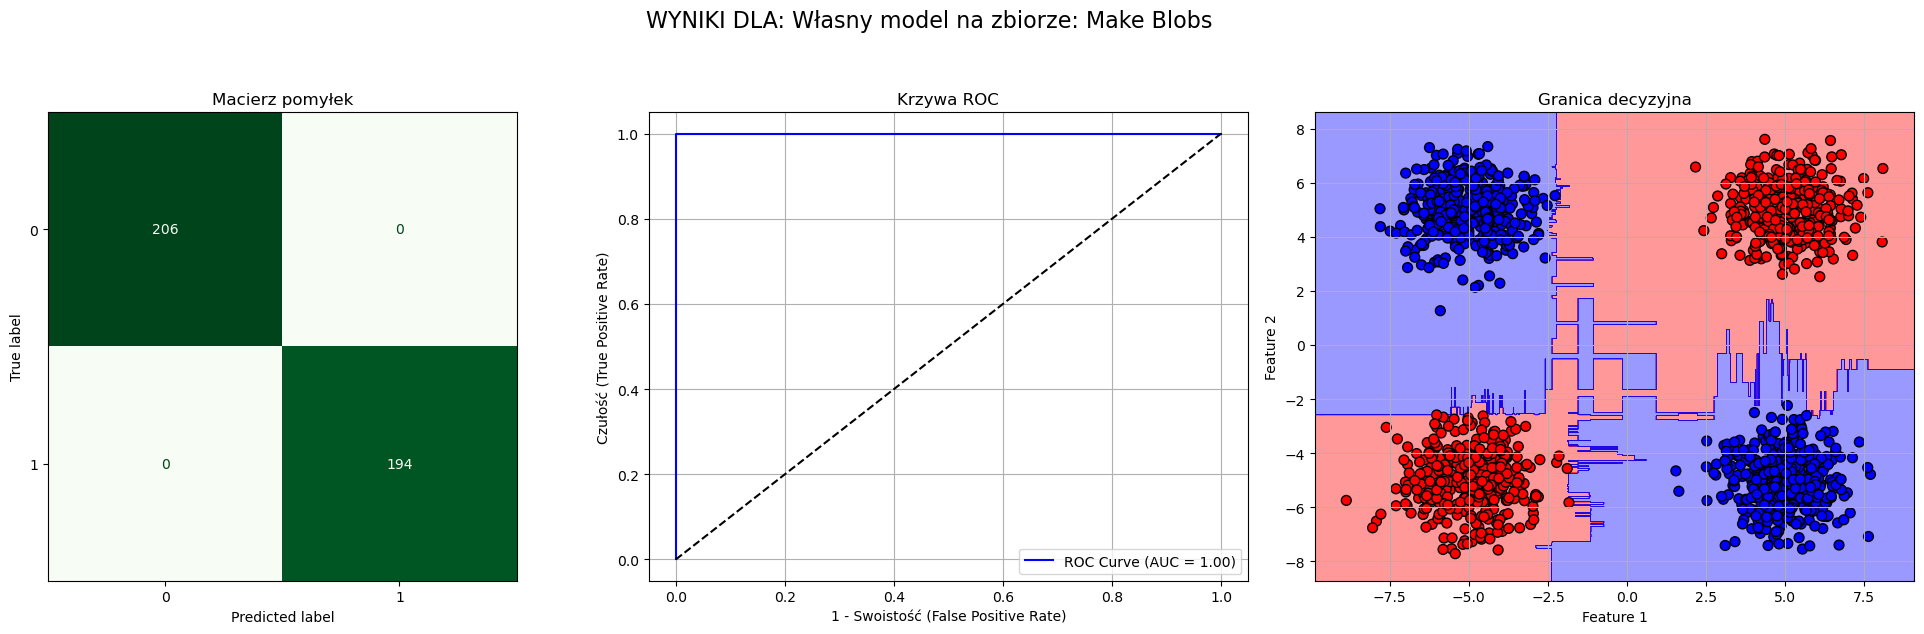

Czas wykonania modelu sklearn: 0.551973 sekund
Sklearn na Make Blobs:
Skuteczność: 100.0000%
Czułość (Recall): 100.0000%
Swoistość: 100.0000%
ROC AUC: 1.0000


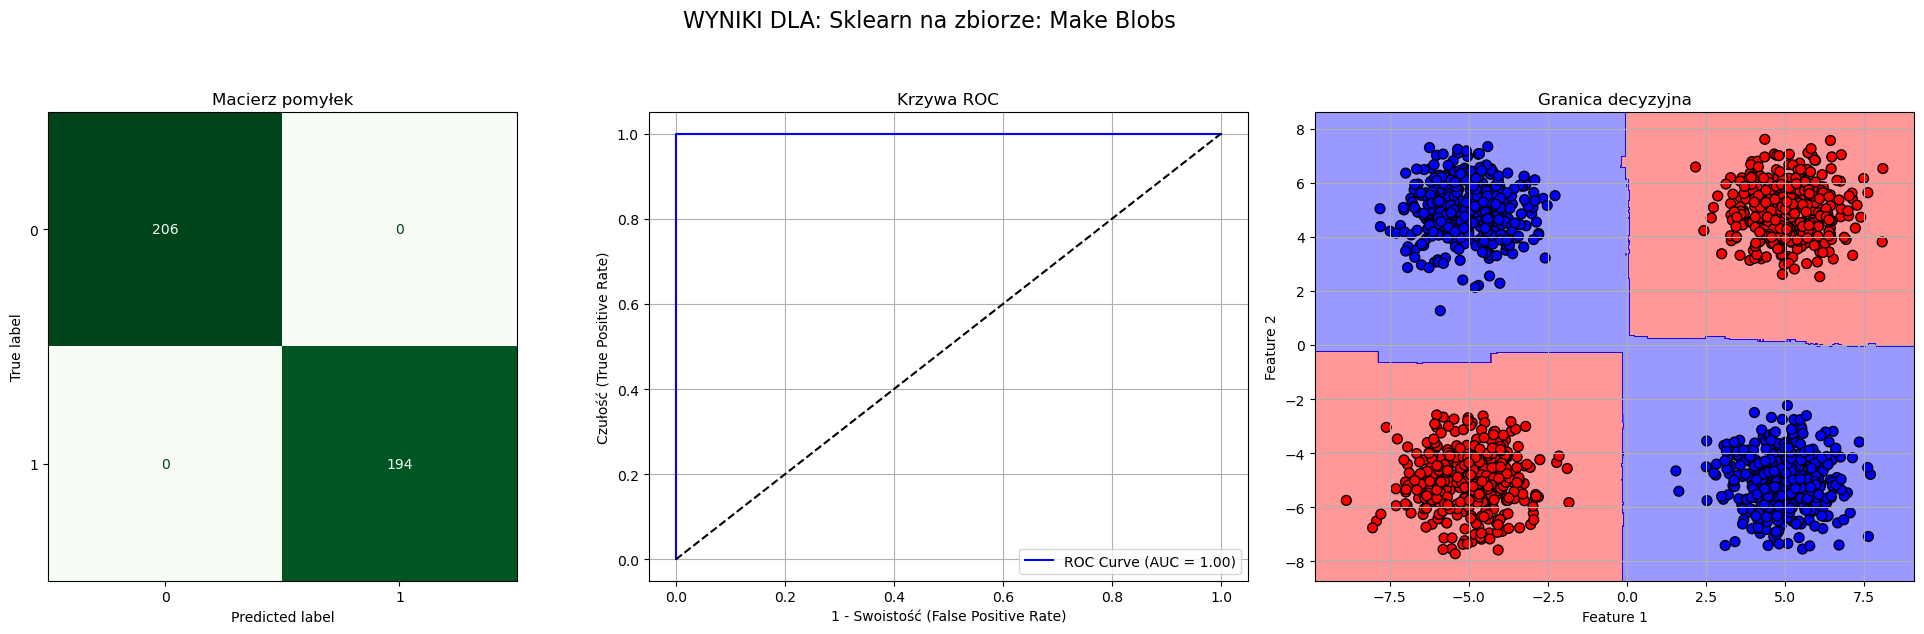

In [10]:
X_blobs, y_blobs = generate_blobs(2000, 2, 259195, split_data=[0, 3])
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_blobs, y_blobs, test_size=0.2, random_state=259195)

n_estimators_3 = select_n_estimators(X_b_train, y_b_train)
print(f"Znaleziona liczba drzew: {n_estimators_3}")

start = time.time()
for _ in range(10):
    rf3 = RandomForest(n_trees=n_estimators_3, max_depth=10)
    rf3.fit(X_b_train, y_b_train)
    y3_pred = rf3.predict(X_b_test)
end = time.time()
print(f"Czas wykonania własnego modelu: {end - start:.6f} sekund")
evaluate_classifier(y_b_test, y3_pred, X_b_train, y_b_train, rf3, "Własny model", "Make Blobs")

start = time.time()
for _ in range(10):
    sk_rf3 = RandomForestClassifier(n_estimators=n_estimators_3, max_depth=10, max_features='sqrt', oob_score=True, bootstrap=True, random_state=42)
    sk_rf3.fit(X_b_train, y_b_train)
    sk_y3_pred = sk_rf3.predict(X_b_test)
end = time.time()
print(f"Czas wykonania modelu sklearn: {end - start:.6f} sekund")
evaluate_classifier(y_b_test, sk_y3_pred, X_b_train, y_b_train, sk_rf3, "Sklearn", "Make Blobs")

## 6.2 Analiza zbioru NASA JPL Asteroid w oparciu o las losowy

In [59]:
import pandas as pd
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


data = pd.read_csv('NASA_JPL_asteroid.csv')
data

C:\Users\jasin\AppData\Local\Temp\ipykernel_18508\3924342103.py:9: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('NASA_JPL_asteroid.csv')


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.400,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.200,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.330,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.000,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.900,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,bPLS6013,3246801,(6013 P-L),6013 P-L,NaN,NaN,N,N,17.135,NaN,...,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,MBA,0.23839
958520,bPLS6331,3246834,(6331 P-L),6331 P-L,NaN,NaN,N,N,18.500,NaN,...,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,MBA,0.53633
958521,bPLS6344,3013075,(6344 P-L),6344 P-L,NaN,NaN,Y,Y,20.400,NaN,...,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,APO,0.51556
958522,bT2S2060,3246457,(2060 T-2),2060 T-2,NaN,NaN,N,N,18.071,NaN,...,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,MBA,0.25641


#### Preprocessing danych

Kolumny do usunięcia zostały rozpatrzone przy pomocy informacji na stronie:
*https://www.kaggle.com/datasets/shrutimehta/nasa-asteroids-classification*, na podstawie opisów kolumn i ich histogramów.

Są to w większości kolumny zawierające nieistotne dane, mało znaczące wartości ID, daty lub nazwy.

In [60]:
columns_to_drop = [
    'full_name', 'orbit_id', 'id', 'spkid', 'pdes', 'name', 'prefix',
    'equinox',
    'moid_ld', 'per_y', 'epoch', 'epoch_mjd', 'epoch_cal', 'tp', 'tp_cal'
]
data = data.drop(columns=columns_to_drop, errors='ignore')
print(len(data.columns))
data.columns 

30


Index(['neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'e', 'a',
       'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'moid', 'sigma_e',
       'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma',
       'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms'],
      dtype='object')

#### Sprawdzenie braków:

In [61]:
missing_values = data.isnull().sum()
print("Braki danych w każdej kolumnie:")
print(missing_values[missing_values > 0].sort_values(ascending=False))

Braki danych w każdej kolumnie:
albedo            823421
diameter_sigma    822443
diameter          822315
sigma_per          19926
sigma_ad           19926
sigma_a            19922
sigma_q            19922
sigma_w            19922
sigma_om           19922
sigma_i            19922
sigma_n            19922
sigma_e            19922
sigma_tp           19922
sigma_ma           19922
pha                19921
moid               19921
H                   6263
neo                    4
per                    4
ad                     4
rms                    2
ma                     1
dtype: int64


In [62]:
nan_columns = ['albedo', 'diameter_sigma', 'diameter']
data = data.drop(columns=nan_columns, errors='ignore')
# len(f"Finalna ilość cech: {data.columns}")
data.columns

Index(['neo', 'pha', 'H', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n',
       'per', 'moid', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om',
       'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per',
       'class', 'rms'],
      dtype='object')

#### Wydzielenie NEO oraz PHA:

In [63]:
data['neo'] = data['neo'].map({'Y': 1, 'N': 0})
data['pha'] = data['pha'].map({'Y': 1, 'N': 0})

# Oddzielenie cech i etykiet
y_neo = data['neo']
y_pha = data['pha']
X = data.drop(columns=['neo', 'pha'])

print(y_neo, y_pha)

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
958519    0.0
958520    0.0
958521    1.0
958522    0.0
958523    0.0
Name: neo, Length: 958524, dtype: float64 0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
958519    0.0
958520    0.0
958521    1.0
958522    0.0
958523    0.0
Name: pha, Length: 958524, dtype: float64


#### Imputacja danych:

In [70]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = ['class']
print(f"Cecha numeryczne: {numeric_features}")
print(f"Cecha kategoryczne: {categorical_features}")

# Pipeline preprocessingu
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

for col in categorical_features:
    X[col] = X[col].astype('category').cat.codes

preprocessor.fit_transform(X)

Cecha numeryczne: Index(['H', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'moid',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms'],
      dtype='object')
Cecha kategoryczne: ['class']


array([[-7.51396644e+00, -8.61870076e-01, -4.43864895e-03, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-7.06836589e+00,  7.94093743e-01, -4.30995485e-03, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-6.43895511e+00,  1.08410908e+00, -7.21492092e-03, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 1.95504525e+00,  5.44560059e+00, -3.11802824e-03, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 6.57790649e-01,  4.93803806e-01, -1.53375749e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 6.51663641e-01,  1.09929381e+00, -1.84400359e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [71]:
mask = (~y_pha.isnull()) & (~y_neo.isnull())
X= X[mask]
y_neo = y_neo[mask]
y_pha = y_pha[mask]

#### Finalny zbiór danych oraz podział na zbiór testowy i treningowy:

In [72]:
X

,H,e,a,q,i,om,w,ma,ad,n,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,3.400,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,2.979647,0.213885,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,7,0.43301
1,4.200,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,3.411748,0.213345,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,7,0.35936
2,5.330,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,3.353865,0.226129,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,7,0.33848
3,3.000,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,2.570926,0.271609,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,7,0.39980
4,6.900,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,3.065455,0.238661,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,7,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,17.135,0.185919,2.280861,1.856807,5.984416,194.229902,195.442802,342.057565,2.704916,0.286125,...,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,7,0.23839
958520,18.500,0.282920,2.334910,1.674319,8.082280,355.248239,5.216223,260.113042,2.995502,0.276248,...,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,7,0.53633
958521,20.400,0.662446,2.817152,0.950941,4.679278,182.982832,234.894852,240.473601,4.683363,0.208444,...,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,1,0.51556
958522,18.071,0.202053,2.373137,1.893638,0.732484,176.499082,198.026527,355.351127,2.852636,0.269600,...,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,7,0.25641


#### Przygotowanie do GridSearch i ustawienie parametrów

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=259195, class_weight='balanced')
param_grid = {
    'classifier__n_estimators': [20, 30],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

### GridSearch dla różnych hiperparametrów:

#### Klasyfikacja NEO:

In [74]:
from sklearn.model_selection import train_test_split

X_neo_train, X_neo_test, y_neo_train, y_neo_test = train_test_split(X, y_neo, test_size=0.2, random_state=259195, stratify=y_neo)

print(f"Zbiór treningowy: {X_neo_train.shape}, Zbiór testowy: {X_neo_test.shape}")
print(f"NEO: {y_neo_train.shape}, {y_neo_test.shape}")

print("Optymalizacja hiperparametrów dla NEO...")
grid_search_neo = GridSearchCV(
    pipeline,
    param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_neo.fit(X_neo_train, y_neo_train)

Zbiór treningowy: (750879, 25), Zbiór testowy: (187720, 25)
NEO: (750879,), (187720,)
Optymalizacja hiperparametrów dla NEO...
Fitting 2 folds for each of 32 candidates, totalling 64 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['H', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'moid',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sig...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['class'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=259195))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [None, 10],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [20, 30]},
             scoring='accuracy', verbose=1)

Najlepsze parametry dla NEO:
{'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 20} 1.0
Nalepszy estimator na NASA NEO:
Skuteczność: 99.9995%
Czułość (Recall): 99.9782%
Swoistość: 100.0000%
ROC AUC: 0.9999


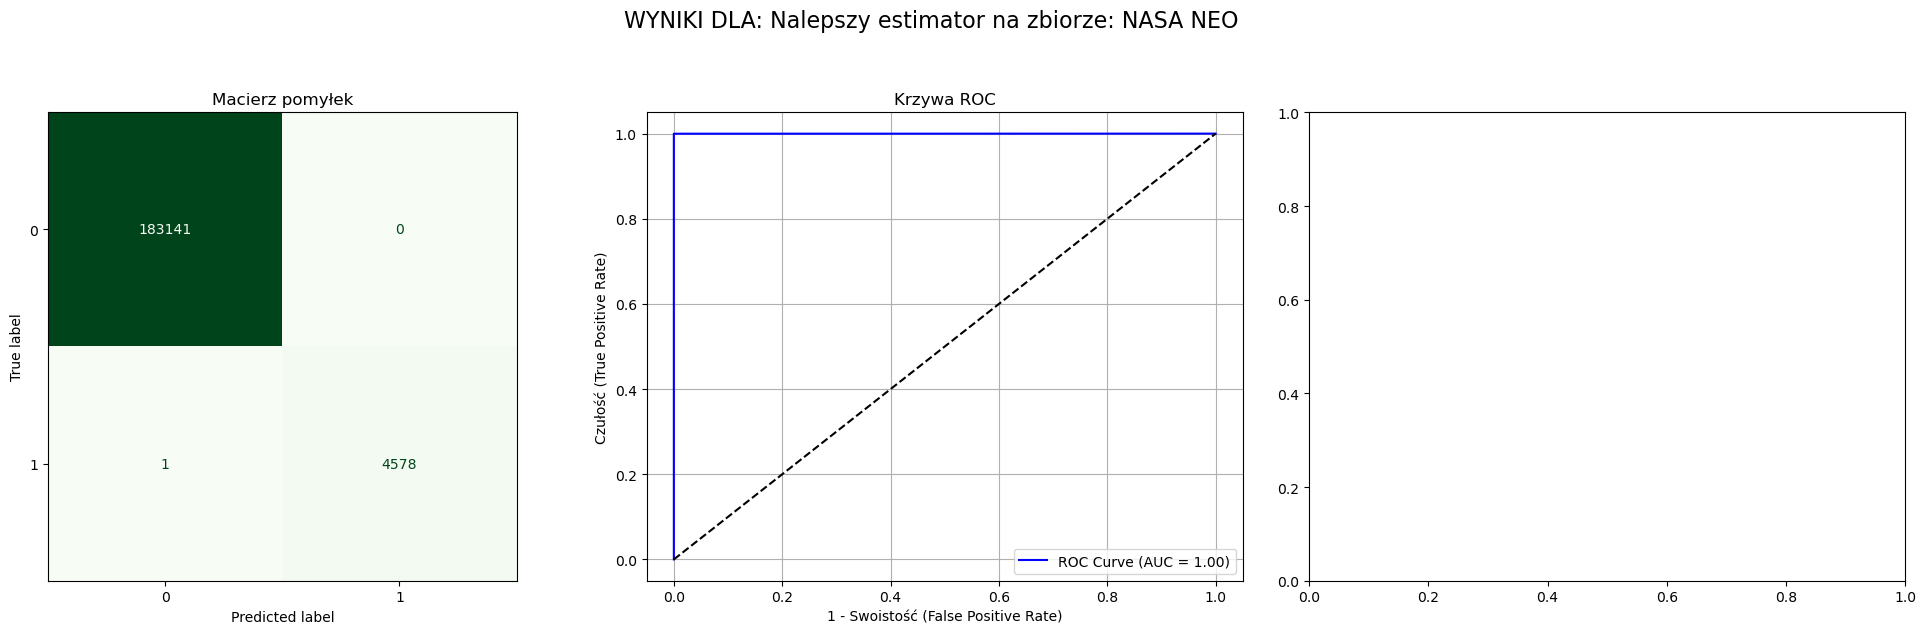

In [75]:
print("Najlepsze parametry dla NEO:")
print(grid_search_neo.best_params_, grid_search_neo.best_score_)

eval_classifier_neo = grid_search_neo.best_estimator_
y_neo_pred = eval_classifier_neo.predict(X_neo_test)
evaluate_classifier(y_neo_test, y_neo_pred, X_neo_train, y_neo_train, eval_classifier_neo, "Nalepszy estimator", "NASA NEO", labels=[0, 1], decision_plot=False)

#### Klasyfikacja PHA:

In [76]:
X_pha_train, X_pha_test, y_pha_train, y_pha_test = train_test_split(
    X, y_pha, test_size=0.2, random_state=259195, stratify=y_pha
)

print("Grid Search dla PHA...")
grid_search_pha = GridSearchCV(
    pipeline,
    param_grid,
    cv=2,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_pha.fit(X_pha_train, y_pha_train)

Grid Search dla PHA...
Fitting 2 folds for each of 32 candidates, totalling 64 fits


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['H', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'per', 'moid',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sig...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['class'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=259195))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [None, 10],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [20, 30]},
             scoring='accuracy', verbose=1)

Najlepsze parametry dla PHA:
{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 30} 0.9998947899426669
Nalepszy estimator na NASA PHA:
Skuteczność: 99.9920%
Czułość (Recall): 98.3051%
Swoistość: 99.9957%
ROC AUC: 0.9915


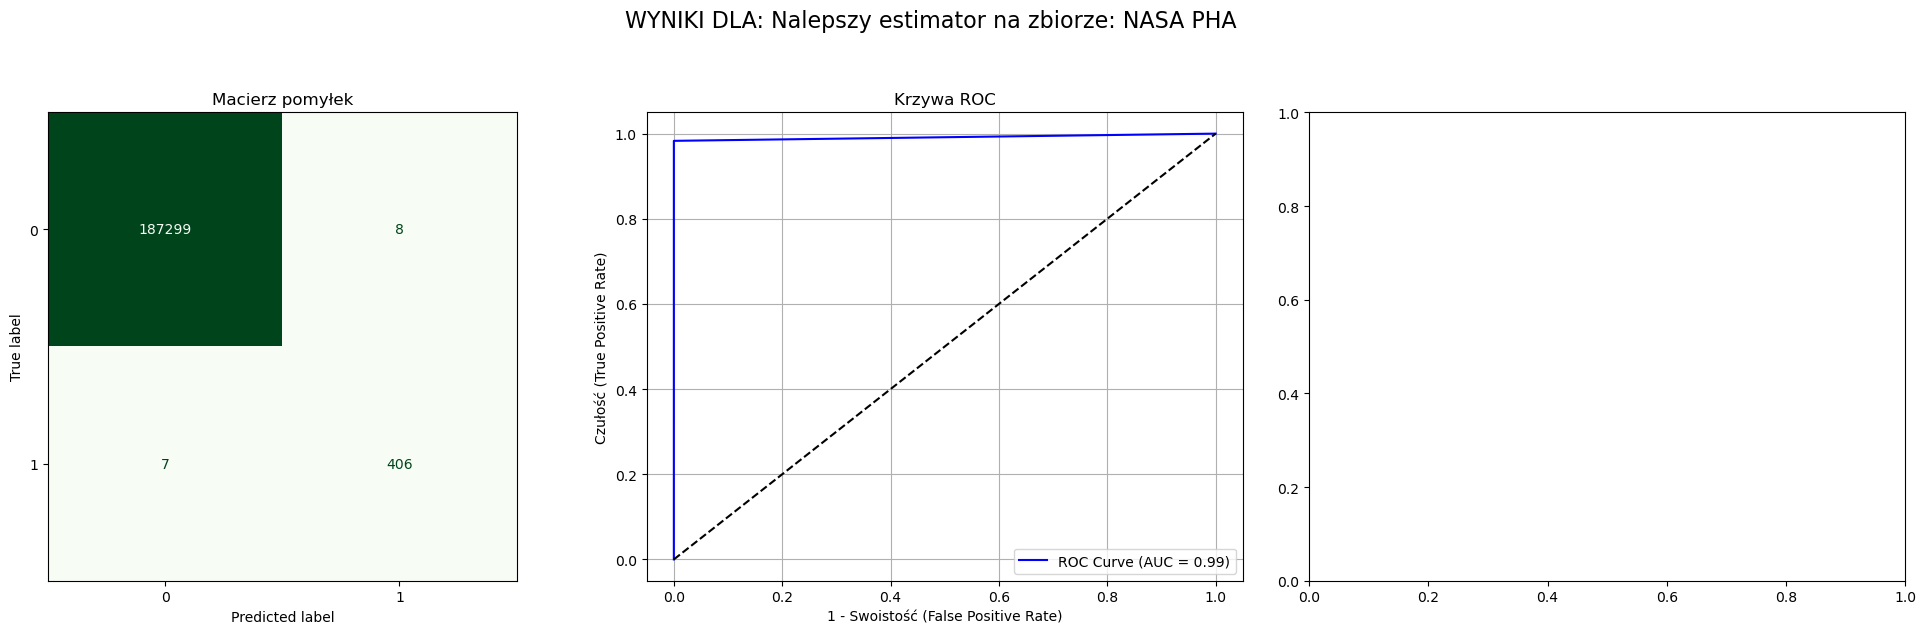

In [77]:
print("Najlepsze parametry dla PHA:")
print(grid_search_pha.best_params_, grid_search_pha.best_score_)

eval_classifier_pha = grid_search_pha.best_estimator_
y_pha_pred = eval_classifier_pha.predict(X_pha_test)
evaluate_classifier(y_pha_test, y_pha_pred, X_pha_train, y_pha_train, eval_classifier_pha, "Nalepszy estimator", "NASA PHA", labels=[0, 1], decision_plot=False)

### 6.3 Analiza wpływu wielkości lasu na jego skuteczność

In [87]:
X_final_train, X_final_test, y_final_train, y_final_test = train_test_split(X, y_neo, test_size=0.1, train_size=0.5, random_state=42, stratify=y_neo)

n_trees = [1, 2, 3, 4, 5, 10, 15, 20, 30]
results_sklearn = {
    'n_trees': [1, 2, 3, 4, 5, 10, 15, 20, 30],
    'avg_time': [],
    'avg_accuracy': [],
}


#### Metoda *sklearn*:

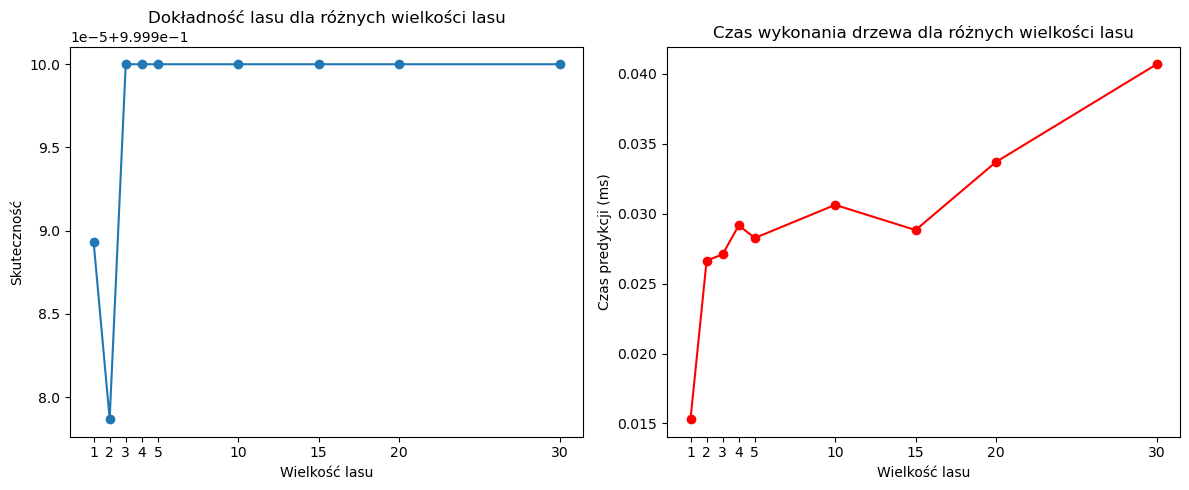

In [ ]:
import time

for n in n_trees:
    times = []
    accuracies = []
    for _ in range(5):
        
        rf = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
        rf.fit(X_final_train, y_final_train)

        start = time.time()    
        y_pred = rf.predict(X_final_test)
        end = time.time()

        accuracy = accuracy_score(y_final_test, y_pred)
    
        times.append(end - start)
        accuracies.append(accuracy)

    results_sklearn['avg_time'].append(np.mean(times))
    results_sklearn['avg_accuracy'].append(np.mean(accuracies))

results_sklearn_df = pd.DataFrame(results_sklearn)


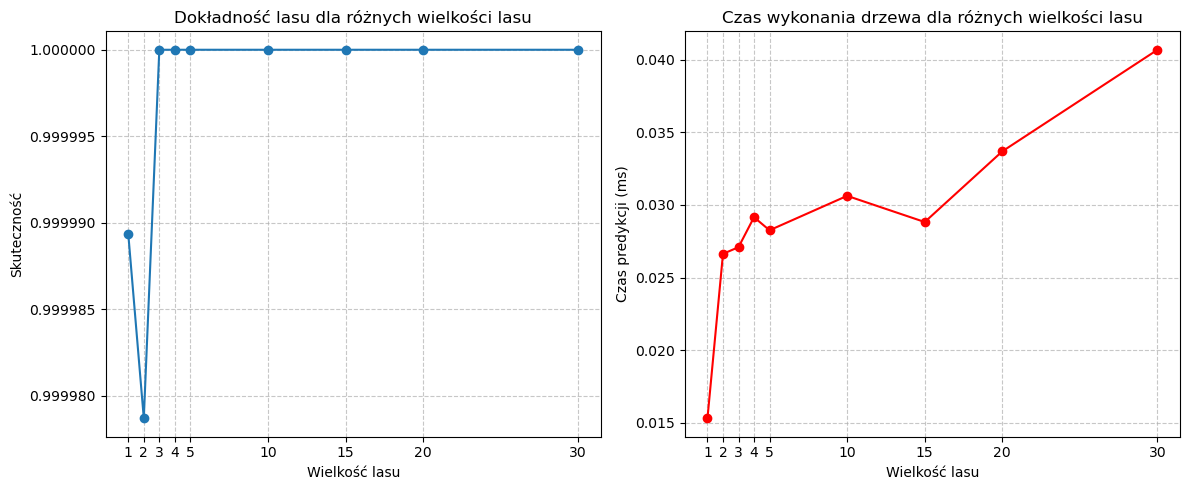

In [129]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def format_six_decimals(x, _):
    return f'{x:.6f}'

def format_three_decimals(x, _):
    return f'{x:.3f}'

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_sklearn_df['n_trees'], results_sklearn_df['avg_accuracy'], marker='o')
plt.title("Dokładność lasu dla różnych wielkości lasu")
plt.xlabel("Wielkość lasu")
plt.ylabel("Skuteczność")
plt.xticks(results_sklearn_df['n_trees'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_six_decimals))
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(results_sklearn_df['n_trees'], results_sklearn_df['avg_time'], marker='o', color='red')
plt.title("Czas wykonania drzewa dla różnych wielkości lasu")
plt.xlabel("Wielkość lasu")
plt.ylabel("Czas predykcji (ms)")
plt.xticks(results_sklearn_df['n_trees'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_three_decimals))
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#### Własna implementacja:

In [121]:
results_own = {
    'n_trees': [1, 2, 3, 4, 5, 10, 15, 20, 30],
    'avg_time': [],
    'avg_accuracy': [],
}

for n in n_trees:
    times = []
    accuracies = []
    for _ in range(5):
        
        rf = RandomForest(n_trees=n, max_depth=10)
        rf.fit(X_final_train.to_numpy(), y_final_train.to_numpy())

        start = time.time()    
        y_pred = rf.predict(X_final_test.to_numpy())
        end = time.time()

        accuracy = accuracy_score(y_final_test, y_pred)
    
        times.append(end - start)
        accuracies.append(accuracy)

    results_own['avg_time'].append(np.mean(times))
    results_own['avg_accuracy'].append(np.mean(accuracies))

results_own_df = pd.DataFrame(results_own)

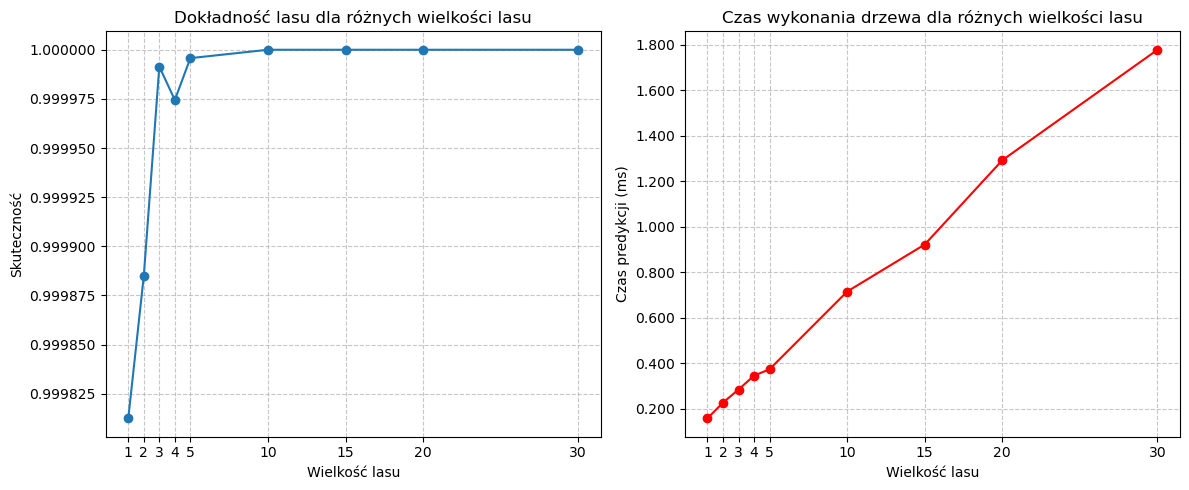

In [130]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_own_df['n_trees'], results_own_df['avg_accuracy'], marker='o')
plt.title("Dokładność lasu dla różnych wielkości lasu")
plt.xlabel("Wielkość lasu")
plt.ylabel("Skuteczność")
plt.xticks(results_own_df['n_trees'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_six_decimals))
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(results_own_df['n_trees'], results_own_df['avg_time'], marker='o', color='red')
plt.title("Czas wykonania drzewa dla różnych wielkości lasu")
plt.xlabel("Wielkość lasu")
plt.ylabel("Czas predykcji (ms)")
plt.xticks(results_own_df['n_trees'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_three_decimals))
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()